#LAB 04

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("spam_or_not_spam.csv")

In [ ]:
display(df.head())

,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
print(df.isnull().sum())

email    1
label    0
dtype: int64


In [ ]:
df = df.dropna(subset=['email'])
df['email'] = df['email'].astype(str)
print("Dataset shape after cleaning :", df.shape)

Dataset shape after cleaning : (2999, 2)


In [ ]:
X = df['email']
y = df['label']

In [ ]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_tfidf = tfidf.fit_transform(X).toarray()

print("Shape after TF-IDF:", X_tfidf.shape)


Shape after TF-IDF: (2999, 5000)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 2399
Testing samples: 600


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
#Model Building
from tensorflow.keras.optimizers import Adam
lr = 0.0005
optimizer = Adam(learning_rate=lr)

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])


model.compile(
    optimizer= optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,449 (2.47 MB)

 Trainable params: 648,449 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Model Training

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)


Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8082 - loss: 0.5664 - val_accuracy: 0.8333 - val_loss: 0.3788
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8833 - loss: 0.2489 - val_accuracy: 0.9604 - val_loss: 0.1574
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9854 - loss: 0.0836 - val_accuracy: 0.9771 - val_loss: 0.0707
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9932 - loss: 0.0313 - val_accuracy: 0.9875 - val_loss: 0.0504
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9974 - loss: 0.0143 - val_accuracy: 0.9875 - val_loss: 0.0501
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9974 - loss: 0.0096 - val_accuracy: 0.9875 - val_loss: 0.0445
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9995 - loss: 0.0055 - val_accuracy: 0.9875 - val_loss: 0.0477
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9990 - loss: 0.0041 - val_accuracy: 0.9896 - v

In [ ]:
# Model Evaluation

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [ ]:
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.9933333333333333

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       500
           1       1.00      0.96      0.98       100

    accuracy                           0.99       600
   macro avg       1.00      0.98      0.99       600
weighted avg       0.99      0.99      0.99       600

Confusion Matrix:

[[500   0]
 [  4  96]]


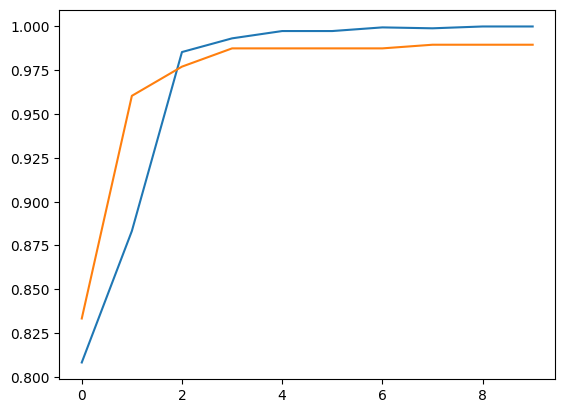

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

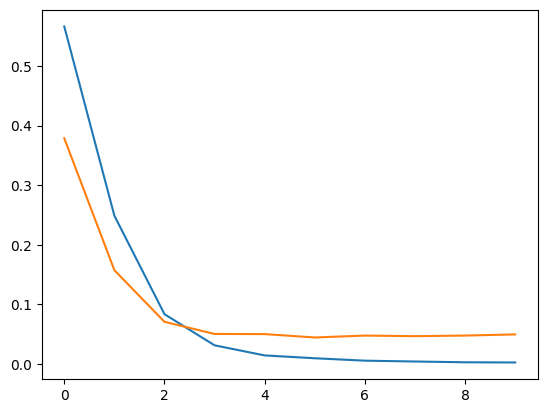

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])